In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# Cargar el dataset

In [2]:
url = "https://raw.githubusercontent.com/erickedu85/dataset/refs/heads/master/adult/adult.data"

column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

df = pd.read_csv(url, names=column_names)


In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()

print("Columnas numéricas:")
print(numeric_columns)

print("\nColumnas categóricas:")
print(categorical_columns)

missing_values = df.isna().sum().rename("valores_nan").to_frame()
display(missing_values)

Columnas numéricas:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Columnas categóricas:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


,valores_nan
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [6]:
for column in categorical_columns:
    print(f"\n{column}:")
    display(df[column].value_counts(dropna=False).rename("frecuencia").to_frame())


workclass:


,frecuencia
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7



education:


,frecuencia
education,
HS-grad,10501
Some-college,7291
Bachelors,5355
Masters,1723
Assoc-voc,1382
11th,1175
Assoc-acdm,1067
10th,933
7th-8th,646



marital-status:


,frecuencia
marital-status,
Married-civ-spouse,14976
Never-married,10683
Divorced,4443
Separated,1025
Widowed,993
Married-spouse-absent,418
Married-AF-spouse,23



occupation:


,frecuencia
occupation,
Prof-specialty,4140
Craft-repair,4099
Exec-managerial,4066
Adm-clerical,3770
Sales,3650
Other-service,3295
Machine-op-inspct,2002
?,1843
Transport-moving,1597



relationship:


,frecuencia
relationship,
Husband,13193
Not-in-family,8305
Own-child,5068
Unmarried,3446
Wife,1568
Other-relative,981



race:


,frecuencia
race,
White,27816
Black,3124
Asian-Pac-Islander,1039
Amer-Indian-Eskimo,311
Other,271



sex:


,frecuencia
sex,
Male,21790
Female,10771



native-country:


,frecuencia
native-country,
United-States,29170
Mexico,643
?,583
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100



income:


,frecuencia
income,
<=50K,24720
>50K,7841


# Limpieza

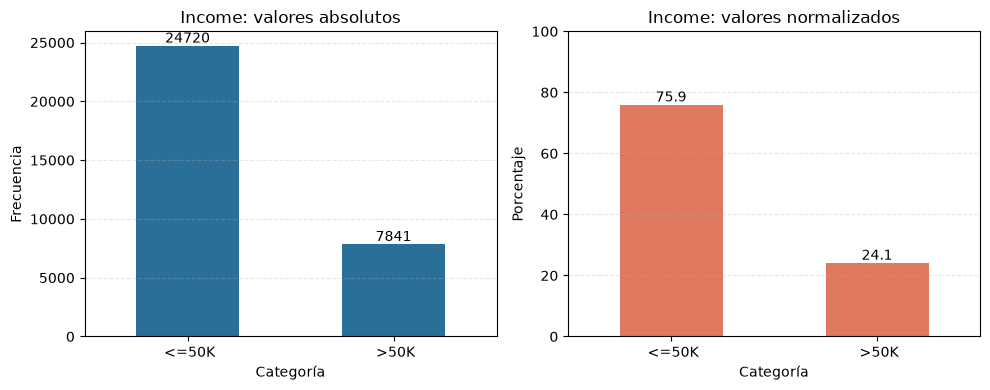

In [7]:


income_counts = df["income"].value_counts(dropna=False)
income_percentages = income_counts.div(income_counts.sum()).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
income_counts.plot(kind="bar", ax=axes[0], color="#2a6f97")
income_percentages.plot(kind="bar", ax=axes[1], color="#e07a5f")

axes[0].set_title("Income: valores absolutos")
axes[0].set_xlabel("Categoría")
axes[0].set_ylabel("Frecuencia")
axes[1].set_title("Income: valores normalizados")
axes[1].set_xlabel("Categoría")
axes[1].set_ylabel("Porcentaje")
axes[1].set_ylim(0, 100)

for ax in axes:
    ax.bar_label(ax.containers[0], fmt="%.1f" if ax is axes[1] else "%.0f")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

fig.tight_layout()
plt.show()

In [8]:
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns
df[categorical_columns] = df[categorical_columns].apply(lambda values: values.str.strip())

In [9]:
categorical_columns = df.select_dtypes(include=["object", "string", "category"]).columns
df[categorical_columns] = df[categorical_columns].apply(
    lambda values: values.str.strip().replace("?", pd.NA)
)

In [10]:
df.isna().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(24)

In [12]:
duplicate_rows = df[df.duplicated(keep=False)].sort_values(
    by=column_names,
    na_position="last"
)
print(f"Filas involucradas en duplicados: {len(duplicate_rows)}")
display(duplicate_rows)

Filas involucradas en duplicados: 47


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
17673,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
6990,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
15189,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
21490,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
3917,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
31993,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
5805,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K


# Configuracion

In [13]:
TEST_SIZE = 0.2
RANDOM_STATE = 42
TARGET = "income"

# Train test split

In [14]:

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[TARGET]
)

X_train = train_df.drop(columns=TARGET)
y_train = train_df[TARGET]
X_test = test_df.drop(columns=TARGET)
y_test = test_df[TARGET]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_train: (26048, 14)
y_train: (26048,)
X_test: (6513, 14)
y_test: (6513,)


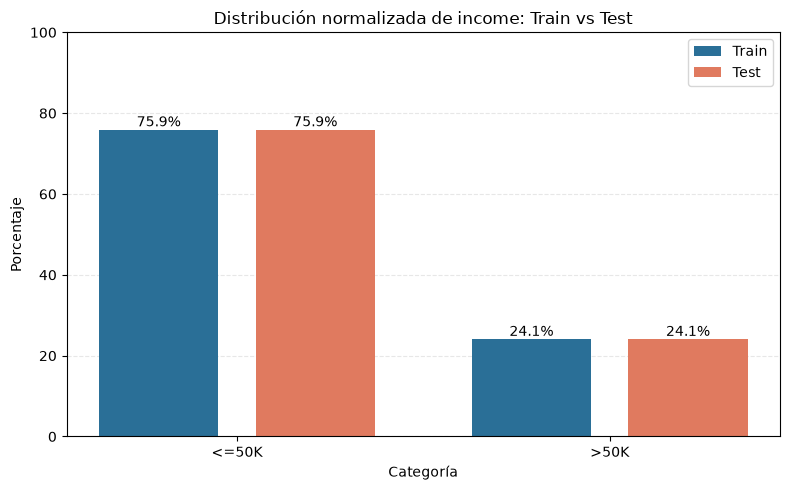

In [15]:
target_split_percentages = pd.DataFrame({
    "Train": train_df[TARGET].value_counts(normalize=True).mul(100),
    "Test": test_df[TARGET].value_counts(normalize=True).mul(100),
}).sort_index()

positions = range(len(target_split_percentages))
bar_width = 0.32
bar_offset = 0.21

fig, ax = plt.subplots(figsize=(8, 5))
train_bars = ax.bar(
    [position - bar_offset for position in positions],
    target_split_percentages["Train"],
    width=bar_width,
    color="#2a6f97",
    label="Train"
)
test_bars = ax.bar(
    [position + bar_offset for position in positions],
    target_split_percentages["Test"],
    width=bar_width,
    color="#e07a5f",
    label="Test"
)

ax.set_title(f"Distribución normalizada de {TARGET}: Train vs Test")
ax.set_xlabel("Categoría")
ax.set_ylabel("Porcentaje")
ax.set_xticks(range(len(target_split_percentages)), target_split_percentages.index)
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.legend()

ax.bar_label(train_bars, fmt="%.1f%%")
ax.bar_label(test_bars, fmt="%.1f%%")
fig.tight_layout()
plt.show()

In [16]:
# from sklearn.impute import SimpleImputer

# occupation_imputer = SimpleImputer(strategy="most_frequent")

# X_train["occupation"] = occupation_imputer.fit_transform(
#     X_train[["occupation"]]
# ).ravel()

# X_test["occupation"] = occupation_imputer.transform(
#     X_test[["occupation"]]
# ).ravel()

# print(f"NaN en occupation de train: {X_train['occupation'].isna().sum()}")
# print(f"NaN en occupation de test: {X_test['occupation'].isna().sum()}")
# print(f"Categoría imputada: {occupation_imputer.statistics_[0]}")

In [17]:
numeric_features = [
    feature
    for feature in X_train.select_dtypes(include="number").columns
    if feature != "education-num"
]
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_features_to_encode = [
    feature for feature in categorical_features if feature != "education"
]


print("Columnas numéricas:")
print(numeric_features)
print("\nColumnas categóricas:")
print(categorical_features)

Columnas numéricas:
['age', 'fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']

Columnas categóricas:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


# Preprocesamiento

## Variables numéricas y categóricas

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_pipeline, categorical_features_to_encode),
        ("numeric", numeric_pipeline, numeric_features)
    ],
    remainder="drop"
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print(f"X_train preprocesado: {X_train_preprocessed.shape}")
print(f"X_test preprocesado: {X_test_preprocessed.shape}")
print(f"education excluida del preprocesamiento: {'education' not in categorical_features_to_encode and 'education' not in numeric_features}")

X_train preprocesado: (26048, 88)
X_test preprocesado: (6513, 88)
education excluida del preprocesamiento: True


# Regresion Logistica

## Fit del modelo

In [19]:
from sklearn.linear_model import LogisticRegression

logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(X_train_preprocessed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

## Predicciones

In [20]:
y_pred = logistic_regression_model.predict(X_test_preprocessed)
y_pred[:10]

array(['<=50K', '<=50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K',
       '<=50K', '<=50K', '<=50K'], dtype=object)

## Valor real, predicciones, probablidades

In [21]:
positive_class_index = list(logistic_regression_model.classes_).index(">50K")
prediction_table = pd.DataFrame({
    "valor_real": y_test.to_numpy(),
    "probabilidad_>50K": logistic_regression_model.predict_proba(
        X_test_preprocessed
    )[:, positive_class_index],
    "prediccion": y_pred,
})

display(prediction_table.head(50))

,valor_real,probabilidad_>50K,prediccion
0,<=50K,0.036514,<=50K
1,<=50K,0.022934,<=50K
2,>50K,0.986910,>50K
3,>50K,0.255996,<=50K
4,<=50K,0.136354,<=50K
5,<=50K,0.056381,<=50K
6,<=50K,0.084519,<=50K
7,<=50K,0.363901,<=50K
8,<=50K,0.288416,<=50K
9,<=50K,0.105303,<=50K


,Predicho <=50K,Predicho >50K
Real <=50K,4567,378
Real >50K,650,918


accuracy            0.842162
precision (>50K)    0.708333
recall (>50K)       0.585459
f1-score (>50K)     0.641061
Name: valor, dtype: float64

              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4945
        >50K       0.71      0.59      0.64      1568

    accuracy                           0.84      6513
   macro avg       0.79      0.75      0.77      6513
weighted avg       0.84      0.84      0.84      6513



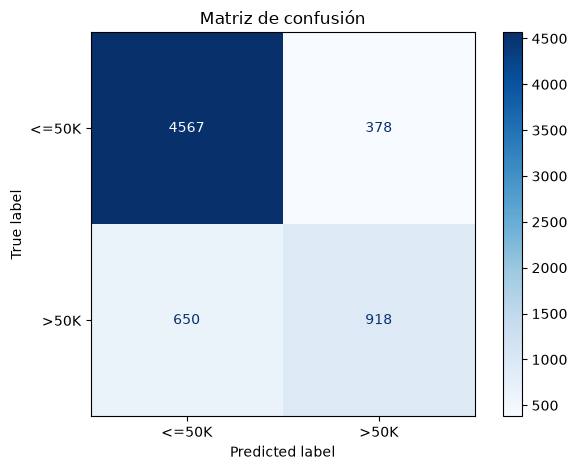

In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

class_labels = ["<=50K", ">50K"]
confusion_matrix_values = confusion_matrix(
    y_test,
    y_pred,
    labels=class_labels
)
confusion_matrix_table = pd.DataFrame(
    confusion_matrix_values,
    index=[f"Real {label}" for label in class_labels],
    columns=[f"Predicho {label}" for label in class_labels],
)
display(confusion_matrix_table)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision (>50K)": precision_score(y_test, y_pred, pos_label=">50K"),
    "recall (>50K)": recall_score(y_test, y_pred, pos_label=">50K"),
    "f1-score (>50K)": f1_score(y_test, y_pred, pos_label=">50K"),
}
display(pd.Series(metrics, name="valor"))
print(classification_report(y_test, y_pred, labels=class_labels, zero_division=0))

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=class_labels,
)
confusion_display.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()

In [23]:
probability_positive = logistic_regression_model.predict_proba(
    X_test_preprocessed
)[:, positive_class_index]
thresholds = [0.3, 0.5, 0.7]
threshold_results = []

for threshold in thresholds:
    threshold_predictions = [
        ">50K" if probability >= threshold else "<=50K"
        for probability in probability_positive
    ]
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, threshold_predictions),
        "precision": precision_score(
            y_test, threshold_predictions, pos_label=">50K", zero_division=0
        ),
        "recall": recall_score(
            y_test, threshold_predictions, pos_label=">50K", zero_division=0
        ),
        "f1": f1_score(
            y_test, threshold_predictions, pos_label=">50K", zero_division=0
        ),
    })

threshold_metrics = pd.DataFrame(threshold_results).set_index("threshold")
metric_deltas = threshold_metrics.subtract(threshold_metrics.loc[0.5])
metric_deltas.columns = [f"{column}_cambio_vs_0.5" for column in metric_deltas.columns]
threshold_comparison = pd.concat([threshold_metrics, metric_deltas], axis=1)
display(threshold_comparison.round(4))

predictions_by_threshold = pd.DataFrame({
    "valor_real": y_test.to_numpy(),
    "probabilidad_>50K": probability_positive,
    **{
        f"prediccion_umbral_{threshold:.1f}": [
            ">50K" if probability >= threshold else "<=50K"
            for probability in probability_positive
        ]
        for threshold in thresholds
    },
})
display(predictions_by_threshold.head(50))

,accuracy,precision,recall,f1,accuracy_cambio_vs_0.5,precision_cambio_vs_0.5,recall_cambio_vs_0.5,f1_cambio_vs_0.5
threshold,,,,,,,,
0.3,0.8128,0.5817,0.7927,0.6710,-0.0293,-0.1267,0.2073,0.0299
0.5,0.8422,0.7083,0.5855,0.6411,0.0000,0.0000,0.0000,0.0000
0.7,0.8174,0.8378,0.2997,0.4415,-0.0247,0.1295,-0.2857,-0.1995


,valor_real,probabilidad_>50K,prediccion_umbral_0.3,prediccion_umbral_0.5,prediccion_umbral_0.7
0,<=50K,0.036514,<=50K,<=50K,<=50K
1,<=50K,0.022934,<=50K,<=50K,<=50K
2,>50K,0.986910,>50K,>50K,>50K
3,>50K,0.255996,<=50K,<=50K,<=50K
4,<=50K,0.136354,<=50K,<=50K,<=50K
5,<=50K,0.056381,<=50K,<=50K,<=50K
6,<=50K,0.084519,<=50K,<=50K,<=50K
7,<=50K,0.363901,>50K,<=50K,<=50K
8,<=50K,0.288416,<=50K,<=50K,<=50K
9,<=50K,0.105303,<=50K,<=50K,<=50K
